Imports


In [7]:
import torch

import matplotlib.pyplot as plt

from torchvision import transforms, datasets
from dataloader import RoadDataset
from fcn import FCN

File Paths


In [28]:
IMG_PATH = "../dataset/data/training/images/"
GTRUTH_PATH = "../dataset/data/training/groundtruth/"
TEST_PATH = "../dataset/data/test/images/"

Parameters

In [8]:
PARAMS = {"batch_size": 64, "shuffle": True, "num_workers": 4}
MAX_EPOCHS = 100

Define Transforms

In [22]:
transforms = transforms.Compose([transforms.RandomRotation(180), transforms.ToTensor()])

Data Load

In [16]:
train_set = RoadDataset(IMG_PATH, GTRUTH_PATH)
train_generator = torch.utils.data.DataLoader(train_set, **PARAMS)

In [17]:
test_set = RoadDataset(TEST_PATH)
test_generator = torch.utils.data.DataLoader(
    test_set, **PARAMS
)  # this will return only one thing

In [9]:
test_file = RoadDataset(
    "../dataset/data/np_files/", gtruth_dir=None, transform=None, img_npy=True
)

In [3]:
import numpy as np

im = np.load("../dataset/data/np_files/TRG_0.png.npy")

In [6]:
type(im)

numpy.ndarray

In [10]:
gen = torch.utils.data.DataLoader(test_file, **PARAMS)

In [11]:
for image in gen:
    res = image

In [12]:
type(res)

torch.Tensor

In [13]:
res.shape

torch.Size([1, 400, 400])

In [14]:
res = res.permute(1, 2, 0)

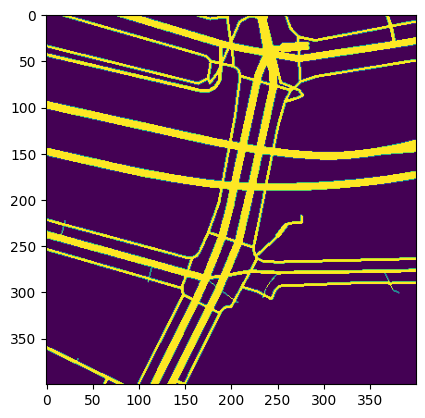

In [15]:
plt.imshow(res)

Loading models and such

Testing data loaded properly

In [18]:
images, gtruths = [], []
for image, mask in train_generator:
    images.append(image)
    gtruths.append(mask)

In [10]:
for i in images:
    print(i.shape)

torch.Size([64, 3, 400, 400])
torch.Size([64, 3, 400, 400])
torch.Size([16, 3, 400, 400])


In [11]:
image_ex, mask_ex = images[0][0], gtruths[0][0]

In [12]:
image_ex = image_ex.permute(1, 2, 0)
mask_ex = mask_ex.permute(1, 2, 0)

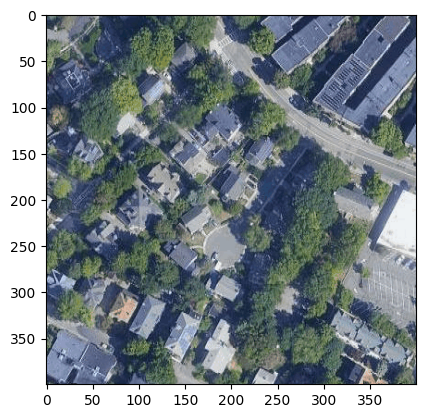

In [13]:
plt.imshow(image_ex)

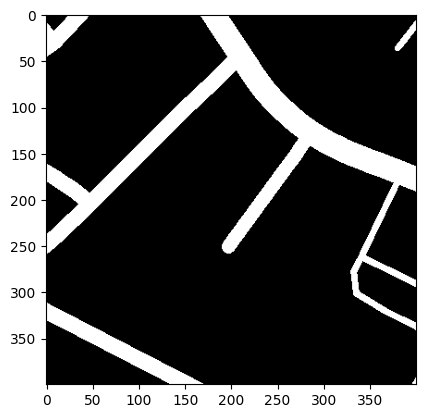

In [14]:
plt.imshow(mask_ex)

In [15]:
test_images = []
for test_image in test_generator:
    test_images.append(test_image)

for i in test_images:
    print(i.shape)

torch.Size([64, 3, 400, 400])
torch.Size([64, 3, 400, 400])
torch.Size([16, 3, 400, 400])
